In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [7]:
nu = np.array([[-1, -1, 1, 0],[1, 1, -1, 0],[0,1,-1,1]]) # stochiometric vectors

def aCalc(c, x):
    a1 = c[0]*(x[0]*x[1])*(x[0]>=1 and x[1]>=1)
    a2 = c[1]*(x[2])*(x[2]>=1)
    a3 = c[2]*(x[2])*(x[2]>=1)
    return np.array([a1, a2, a3])

## Section 3.1

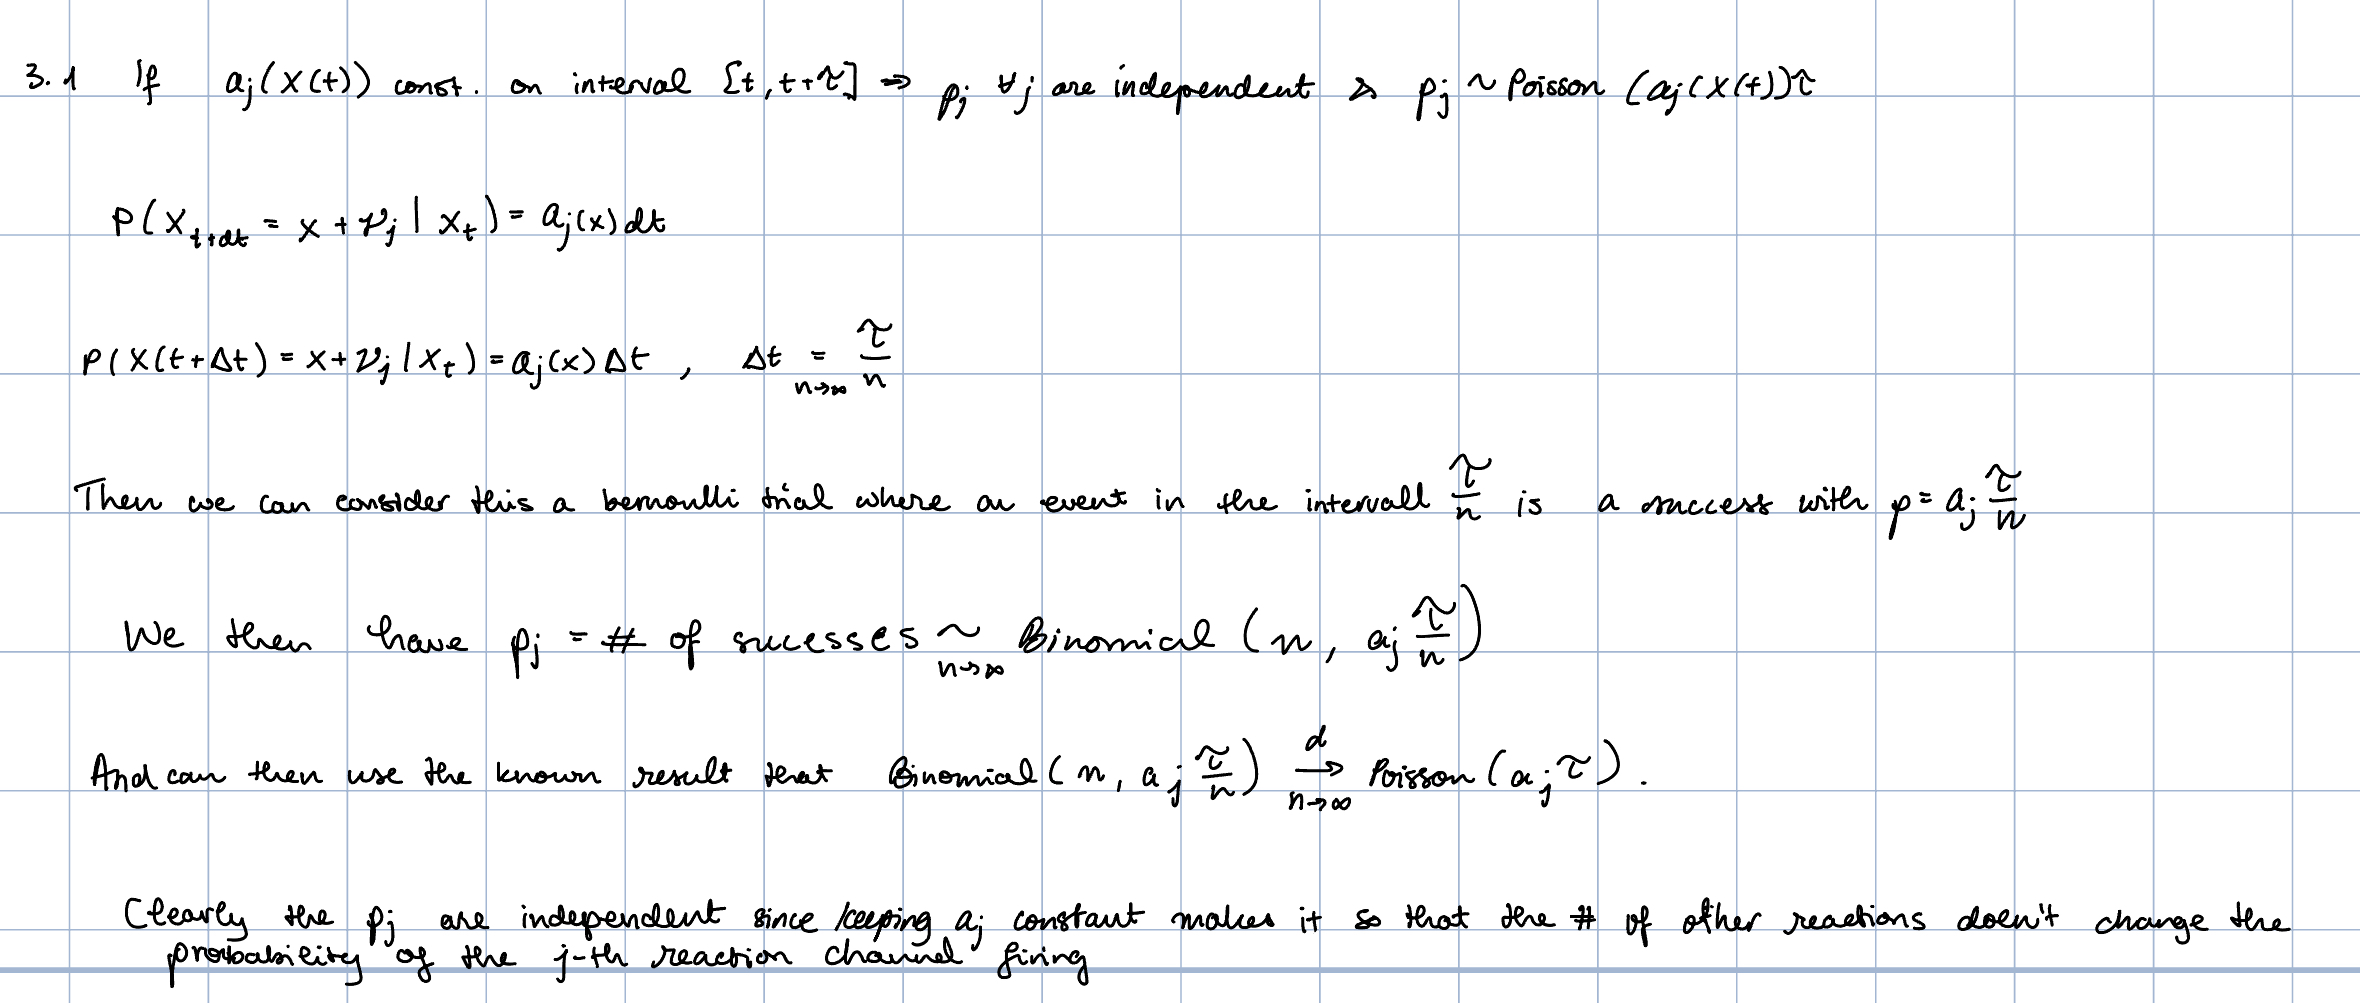

### 3.1.2

Implementing tau-leaping algorithm and using the same rate constants as in section 2.1

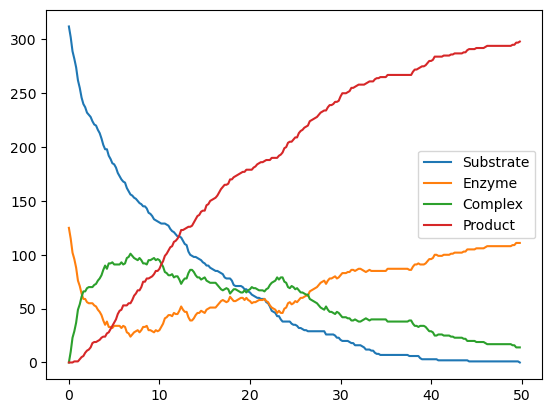

In [17]:
def explicit_tau_leaping(c, X0, T, tau):
    t = np.arange(0, T, tau)
    X = np.zeros((len(t),4))

    X[0]=X0

    for i in range(0, len(t)-1):
        a = aCalc(c, X[i])
        #aSum = sum(a)
        
        P = np.random.poisson(lam = (a*tau)) # (3,) array of pj values
        X[i+1] = X[i] + P @ nu
    return t, X


c = [0.0017, 1e-4, 0.1] # rate constants

T = 50 # Total time
tau = 0.2

X0 = [312, 125, 0, 0] # Initial # of each species

t, X = explicit_tau_leaping(c, X0, T, tau)
X = np.transpose(X)
n = len(t)-1
plt.plot(t, X[0], label="Substrate")
plt.plot(t, X[1], label="Enzyme")
plt.plot(t, X[2], label="Complex")
plt.plot(t, X[3], label="Product")
plt.legend()
plt.show()

### 3.1.3
Estimating Zdelt = E[X4(T)]

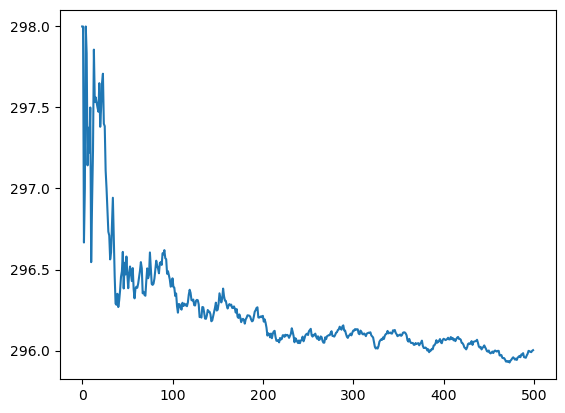

In [ ]:
'''
Test plot to estimate a good Nb
'''

Nb = 500
X4 = np.zeros(Nb)
muNs= [0]

for i in range(Nb):
    t, X = explicit_tau_leaping(c, X0, T, tau)
    X4[i] = X[-1,3]
    muNs.append((i/(i+1))*muNs[-1] + 1/(i+1) * X[-1,3])
    
plt.plot(range(0, Nb), muNs[1:])

In [ ]:
Nb = 150
X4 = np.zeros(Nb)
muNs= [0]
for i in range(Nb):
    t, X = explicit_tau_leaping(c, X0, T, tau)
    X4[i] = X[-1,3]
    muNs.append((i/(i+1))*muNs[-1] + 1/(i+1) * X[-1,3])
    
alpha = 0.05  # for 95% confidence
cAlph = stats.norm.ppf(1 - alpha/2)
tol = 0.2

muNb = 1/Nb * sum(X4)
sigNb = np.sqrt(1/(Nb-1) * sum((X4 - muNb)**2))

N, muN, sigN = Nb, muNb, sigNb

while (sigN * cAlph/np.sqrt(N) > tol):
    
    N = N+1
    
    t, X = explicit_tau_leaping(c, X0, T, tau)
    
    muN = (N/(N+1))*muN + 1/(N+1) * X[-1,3]
    sigN = np.sqrt((N-1)/N * sigN**2 + 1/(N+1) * (X[-1,3] - muN)**2)

In [25]:
print("95% confidence interval for mu: [", muN-(sigN * cAlph/np.sqrt(N)),' , ',muN+(sigN * cAlph/np.sqrt(N)),']')
print(f'halfwidth is {sigN * cAlph/np.sqrt(N)}')
print("Calculated by N = ", N, " iterations")

95% confidence interval for mu: [ 295.96116951861376  ,  296.3611256871231 ]
halfwidth is 0.19997808425466226
Calculated by N =  1765  iterations


### 3.1.4

Implicit tau-leaping algorithm

a)

y = X(t) + tau * sum ( aj(y) * nu)
f(y) = y - X(t) - tau * sum ( aj(y) * nu) = 0

y(k+1) = y(k) - inv(jacobi)*f(y(k))

b)

Sampling Pj from poisson(aj(y)*tau)

In [ ]:
nu = np.array([[-1,1,0],
                [-1,1,1],
                [1,-1,-1],
                [0,0,1]])

# propensities, now without indicators for the sake of continuity, so that newton's method converges consistently
def aCalc(c, x):
    a1 = c[0]*(x[0]*x[1])
    a2 = c[1]*(x[2])
    a3 = c[2]*(x[2])
    return np.array([a1, a2, a3])

In [ ]:
# Jacobi, found on paper
J = lambda y: np.array([[1+tau*c[0]*y[1],     tau*c[0]*y[0],        -tau*c[1],               0],
                        [tau*c[0]*y[1],       1 + tau*c[0]*y[0],    -tau*(c[1]+c[2]),        0],
                        [-tau*c[0]*y[1],      -tau*c[0]*y[0],       1 + tau*(c[1]+c[2]),     0],
                        [0,                   0,                    -tau*c[2],               1]])

f = lambda y, a, x: y - x - tau*(nu @ a)

def newtons(X, tol):
    # Initial calculations of y0 and y1
    y0 = X 
    F = f(y0, aCalc(c, y0), X)
    
    y1 = y0 - np.linalg.inv(J(y0)) @ F

    while (np.linalg.norm(f(y1, aCalc(c, y0), X))>tol): # Checking for convergence

        y0 = y1
        F = f(y0, aCalc(c, y0), X)
        y1 = y0 - np.linalg.inv(J(y0))@F
        
    return y1

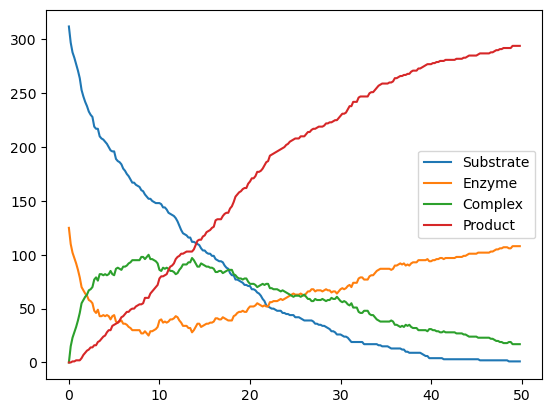

In [ ]:
def implicit_tau_leaping(c, X0, T, tau, tol):
    t = np.arange(0, T, tau)
    X = np.zeros((len(t),4))

    X[0]=X0

    for i in range(0, len(t)-1):
        
        y = newtons(X[i], tol)
        a = np.maximum (aCalc(c, y), 0) # Since we removed the indicators from aCalc for convergence of newton's, we reintroduce the requirement here
        P = np.random.poisson(lam = (a*tau)) # (3,) array of pj values drawn from aj(y)*tau
        X[i+1] = X[i] + nu @ P
    return t, X


c = [0.0017, 1e-4, 0.1] # Rate constants

T = 50 # Total time
tau = 0.2

X0 = [312, 125, 0, 0] # Initial # of each species

t, X = implicit_tau_leaping(c, X0, T, tau, 1e-4)
X = np.transpose(X)

plt.plot(t, X[0], label="Substrate")
plt.plot(t, X[1], label="Enzyme")
plt.plot(t, X[2], label="Complex")
plt.plot(t, X[3], label="Product")
plt.legend()
plt.show()

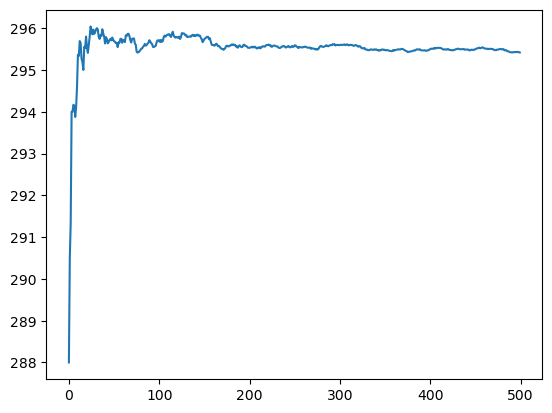

In [45]:
'''
Test plot to estimate a good Nb
'''

Nb = 500
X4 = np.zeros(Nb)
muNs= [0]

for i in range(Nb):
    t, X = implicit_tau_leaping(c, X0, T, tau, 1e-4)
    X4[i] = X[-1,3]
    muNs.append((i/(i+1))*muNs[-1] + 1/(i+1) * X[-1,3])
    
plt.plot(range(0, Nb), muNs[1:])

^^^^ MUCH smoother much faster than the explicit tau leaping algorithm.

In [47]:
Nb = 150
X4 = np.zeros(Nb)
muNs= [0]
for i in range(Nb):
    t, X = implicit_tau_leaping(c, X0, T, tau, 1e-4)
    X4[i] = X[-1,3]
    muNs.append((i/(i+1))*muNs[-1] + 1/(i+1) * X[-1,3])
    
alpha = 0.05  # for 95% confidence
cAlph = stats.norm.ppf(1 - alpha/2)
tolN = 0.2

muNb = 1/Nb * sum(X4)
sigNb = np.sqrt(1/(Nb-1) * sum((X4 - muNb)**2))

N, muN, sigN = Nb, muNb, sigNb

while (sigN * cAlph/np.sqrt(N) > tolN):
    
    N = N+1
    
    t, X = implicit_tau_leaping(c, X0, T, tau, 1e-4)
    
    muN = (N/(N+1))*muN + 1/(N+1) * X[-1,3]
    sigN = np.sqrt((N-1)/N * sigN**2 + 1/(N+1) * (X[-1,3] - muN)**2)

In [49]:
print("95% confidence interval for mu: [", muN-(sigN * cAlph/np.sqrt(N)),' , ',muN+(sigN * cAlph/np.sqrt(N)),']')
print(f'halfwidth is {sigN * cAlph/np.sqrt(N)}')
print("Calculated by N = ", N, " iterations")

95% confidence interval for mu: [ 295.07980535464804  ,  295.47969163824354 ]
halfwidth is 0.19994314179774503
Calculated by N =  1828  iterations
